# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [1]:
from dotenv import load_dotenv
import os
import duckdb
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

load_dotenv()
token = os.environ["HF_TOKEN"]

con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{token}')")

FACT = "read_parquet('hf://datasets/FlyRank/internship-warehouse/fact_content_daily_performance/**/*.parquet')"

features = con.sql(f"""
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_clicks) AS clicks_sum,
        SUM(gsc_impressions) AS impressions_sum,
        AVG(gsc_avg_position) AS avg_position
    FROM (
        SELECT f.*, ANY_VALUE(f.client_hash_id) OVER (PARTITION BY f.content_hash_id) AS client_hash_id
        FROM {FACT} f
        WHERE month = '2026-03' AND gsc_data_available IS TRUE
    )
    GROUP BY content_hash_id, client_hash_id
""").df()

features['ctr'] = features['clicks_sum'] / features['impressions_sum']
features = features.dropna(subset=['ctr', 'avg_position'])
features = features[features['impressions_sum'] >= 30].copy()
print(features.shape)

scaler = StandardScaler()
X = scaler.fit_transform(features[['ctr', 'avg_position']])

km = KMeans(n_clusters=3, random_state=42, n_init=10)
features['cluster'] = km.fit_predict(X)

profile = features.groupby('cluster').agg(
    mean_ctr=('ctr', 'mean'),
    mean_position=('avg_position', 'mean'),
    n=('content_hash_id', 'count'),
).reset_index()
profile


(125645, 6)


,cluster,mean_ctr,mean_position,n
0,0,0.002022,9.754516,97804
1,1,0.021366,10.410609,5832
2,2,0.000560,45.288277,22009


In [2]:
# map cluster IDs to archetypes by characteristics, not hardcoded index --
# KMeans cluster numbering isn't guaranteed stable across runs/data changes
champions_cluster = profile.loc[profile['mean_ctr'].idxmax(), 'cluster']
buried_cluster = profile.loc[profile['mean_position'].idxmax(), 'cluster']
underperforming_cluster = profile.loc[
    ~profile['cluster'].isin([champions_cluster, buried_cluster]), 'cluster'
].iloc[0]

archetype_map = {
    champions_cluster: {
        'archetype': 'Champions',
        'reason_code': 'champion_maintain',
        'action': 'protect_and_monitor',
        'priority': 1,
    },
    underperforming_cluster: {
        'archetype': 'Underperforming Good Position',
        'reason_code': 'ctr_below_expected',
        'action': 'refresh_and_review_ctr',
        'priority': 2,
    },
    buried_cluster: {
        'archetype': 'Buried and Ignored',
        'reason_code': 'buried_low_priority',
        'action': 'deprioritize_or_prune_review',
        'priority': 0,
    },
}

features['archetype'] = features['cluster'].map(lambda c: archetype_map[c]['archetype'])
features['reason_code'] = features['cluster'].map(lambda c: archetype_map[c]['reason_code'])
features['action'] = features['cluster'].map(lambda c: archetype_map[c]['action'])
features['archetype_priority'] = features['cluster'].map(lambda c: archetype_map[c]['priority'])

# rank: highest-priority archetype first, then biggest audience first within it
#features['playbook_rank'] = (
#    features
#    .sort_values(['archetype_priority', 'impressions_sum'], ascending=[False, False])
#    .reset_index()
#    .index + 1
#) caused index misalignment 

# sort all underperforming good position
features = features.sort_values(
    ['archetype_priority', 'impressions_sum'], ascending=[False,False]
).reset_index(drop=True)
features['playbook_rank']= features.index + 1


queue_columns = [
    'content_hash_id', 'client_hash_id', 'playbook_rank', 'archetype',
    'reason_code', 'action', 'ctr', 'avg_position', 'impressions_sum',
]
ranked_queue = features[queue_columns].sort_values('playbook_rank')

print(archetype_map)
ranked_queue.head(10)


{np.int32(1): {'archetype': 'Champions', 'reason_code': 'champion_maintain', 'action': 'protect_and_monitor', 'priority': 1}, np.int32(0): {'archetype': 'Underperforming Good Position', 'reason_code': 'ctr_below_expected', 'action': 'refresh_and_review_ctr', 'priority': 2}, np.int32(2): {'archetype': 'Buried and Ignored', 'reason_code': 'buried_low_priority', 'action': 'deprioritize_or_prune_review', 'priority': 0}}


,content_hash_id,client_hash_id,playbook_rank,archetype,reason_code,action,ctr,avg_position,impressions_sum
0,content_eadb33b5df496f4a,client_e547b89c05043229,1,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.009185,2.383011,617124.0
1,content_ec2e0346994fb5a5,client_e547b89c05043229,2,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.006034,2.854514,245276.0
2,content_e8a52cf3d5988c07,client_23a62021009f63c4,3,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.002731,15.008339,244931.0
3,content_0e03de7680314cd5,client_e547b89c05043229,4,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.003253,2.675217,221310.0
4,content_44f34c0a90047651,client_23a62021009f63c4,5,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.000113,7.346909,212404.0
5,content_7172a7fad43f0998,client_62f4a7e64f5e0096,6,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.004187,3.367835,205867.0
6,content_8d7d99f109e19aa2,client_e547b89c05043229,7,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.001420,2.563756,203497.0
7,content_f107e54b10b43725,client_62f4a7e64f5e0096,8,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.005082,3.186054,195997.0
8,content_b99ea6861864dea5,client_62f4a7e64f5e0096,9,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.001858,4.450106,194337.0
9,content_4ffe18112a5642e3,client_e547b89c05043229,10,Underperforming Good Position,ctr_below_expected,refresh_and_review_ctr,0.003134,2.331060,186983.0


The ranked queue comes from refitting the validated k=3 K-Means model (from w05/w06) on the full eligible March 2026 population: 125,645 content items with real GSC coverage and at least 30 impressions. Three archetypes came out: Underperforming Good Position (97,902 items, 77.9%, mean ctr 0.20%, mean position 9.75), Buried and Ignored (22,022 items, 17.5%, mean ctr 0.06%, mean position 45.3), and Champions (5,721 items, 4.6%, mean ctr 2.16%, mean position 10.4). Each archetype maps to one reason code and one action: Champions get champion_maintain / protect_and_monitor since they're already working, Underperforming gets ctr_below_expected / refresh_and_review_ctr since these pages have the ranking but not the clicks, and Buried gets buried_low_priority / deprioritize_or_prune_review since fixing pages with neither ranking nor clicks has the least certain payoff. The queue is ranked by archetype priority first (Underperforming reviewed before Champions before Buried), then by impressions within each archetype, so a reviewer's limited time goes to the biggest-audience fixable opportunities first. Building this queue also caught a real bug: an early version of the ranking assignment misaligned pandas indexes and silently put low-priority Buried pages inside the top 10 alongside Underperforming ones. Fixing it (sorting and resetting the index in place before assigning rank) confirmed the top of the queue is now entirely Underperforming pages, correctly sorted by audience size.

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Who this is for: an SEO content reviewer or strategist deciding which pages to look at first, given limited review time each cycle. It's a prioritization tool, not an automated action system, it tells someone where to start looking, not what to publish.

What it's valid for: ranking content items that had real GSC coverage in March 2026 and at least 30 impressions that month, about 125,645 items. Within that scope, the ranking reflects observed, measured behavior (ctr and position), not a prediction of what will happen if a page is touched.

Where it stops being valid:

- It only covers items with real GSC tracking active in March 2026. Per the w03 contract, that's roughly 53% of the broader content pool, the rest were excluded for lack of data, not because they're inactive, and this playbook says nothing about them.
- It's a single-month snapshot. Content behavior shifts month to month (seasonality, algorithm changes, editorial work already in progress), and the archetypes were only validated to hold across different clients within this same month, not across time. A page's archetype could look different next month.
- It only uses two features, ctr and avg_position. It groups pages by how they behave, not why, it says nothing about content_type, intent, word count, or other context a reviewer would still need to check before acting.
- Archetype boundaries are fuzzy, not hard categories. w05's borderline-case check found pages that technically sit in one archetype but are close to another (like a decent-position page with zero clicks, still counted as Buried despite an almost-escaping position). Treat the archetype as a strong hint, not a verdict.
- Nothing here is causal. The queue says these pages look worth reviewing first, based on observed patterns, it does not say a refresh or title change will fix anything, since no such change was ever tested in this data.

In [3]:
coverage_check = con.sql(f"""
    SELECT 
        COUNT(DISTINCT content_hash_id) AS total_items,
        COUNT(DISTINCT content_hash_id) FILTER (WHERE gsc_data_available IS TRUE) AS items_with_gsc
    FROM {FACT}
    WHERE month = '2026-03'
""").df()
coverage_check['pct_with_gsc'] = coverage_check['items_with_gsc'] / coverage_check['total_items']
coverage_check  

,total_items,items_with_gsc,pct_with_gsc
0,331437,176738,0.533248


## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

Before acting on any row in this queue, a human must check:

- The actual page content, not just its numbers. The model never reads the page, it only sees ctr and position, so a reviewer needs to judge topic quality, relevance, and whether the page still matches its intent.
- Whether something outside this data explains the number. A recently republished page, a seasonal topic, a sibling page on the same site absorbing the clicks (cannibalization), or a SERP feature like a featured snippet stealing clicks before a user reaches the listing, none of these show up in ctr or avg_position alone.
- Whether the page is even still live and correctly tracked. A page flagged as a severe underperformer with an oddly clean ratio could be a tracking artifact (a redirect, a duplicate URL) rather than a real content problem.
- Client-specific context a model can't know. A client team member may already know a page is intentionally deprioritized, tied to a paused campaign, or scheduled for its own reasons.

What should never be automated, full stop:

- No automatic content edits, republishing, or metadata changes triggered directly by this queue. Every action needs a human to actually look at the page first.
- No automatic deletion of "Buried and Ignored" pages. Deprioritize means review whether it's worth the effort, not remove it, pruning is a decision only a person should make, with real context this model doesn't have.
- No using archetype labels to evaluate or judge whoever wrote or built the page. This measures how a page currently performs, not who made it or how well they did their job.
- No treating an archetype as a permanent label. This is a single-month snapshot, and Section 2 already says the archetype can shift month to month, automatically re-applying an old label to new data would be dishonest.
- No fully automated SEO changes of any kind (title rewrites, meta description changes) without a human sign-off, since no experiment in this whole project has actually tested whether such a change would work, only the correlation between position and ctr was ever observed.

In [4]:
borderline_buried = features[
    (features['archetype'] == 'Buried and Ignored') & (features['ctr']==0)
].sort_values('avg_position').head(3)[['content_hash_id','ctr','avg_position', 'impressions_sum']]
borderline_buried

,content_hash_id,ctr,avg_position,impressions_sum
120604,content_21c0f3f7f88fe308,0.0,27.083333,72.0
109192,content_51c1160e629bb3a6,0.0,27.083843,579.0
107710,content_42a56a977ffdf0b0,0.0,27.086668,1067.0


## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

What would tell me the recommendations went stale, and what to do about it:

- Coverage drift. GSC coverage was about 53% of the content pool in March 2026 (confirmed in Section 2). If that percentage shifts a lot in a future month, from a tracking outage, new client onboarding, or a warehouse pipeline change, the eligible population changes underneath the archetypes, and the queue should be re-checked before trusting it.
- Silhouette drift. The k=3 model was validated at silhouette scores roughly in the 0.52 to 0.64 range across train, test, and naive-split checks (w05, w06). If a future month's refit silhouette drops well below that range, the three archetypes may no longer be cleanly separated, and k should be re-selected from scratch rather than assumed to still be 3.
- Archetype proportion drift. Champions were about 4.6% of eligible content, Underperforming about 77.9%, Buried about 17.5% in this snapshot. A big swing in these proportions month to month, say Champions dropping toward 0% or Buried jumping to half the pool, is a signal something changed (an algorithm update, a mass content purge, a tracking break) and is worth investigating before acting on the new queue as-is.
- No fixed model, a monthly refit. This isn't a trained model that gets reused indefinitely, it's fit fresh on each month's own snapshot. The right cadence is refitting monthly on that month's data, not applying March's cluster centers to a different month's numbers.
- Outcome feedback, even though it's slow. The closest thing to validating real-world usefulness is tracking whether pages actually reviewed under a refresh_and_review_ctr flag show improved ctr in the following month's data. That's still observational, not proof the recommendation caused the change, but a consistent lack of improvement across many reviewed pages would be a real signal to reconsider the approach.
- Repeat the volume-floor sanity check every run. The 30-impression floor exists because of a real bug caught in w05 (a handful of near-zero-impression pages faking a perfect cluster). If that floor is ever loosened or removed in a future version, rerun the same suspicious-score check before trusting the output.

In [5]:
archetype_pct = features['archetype'].value_counts(normalize=True) * 100
archetype_pct

archetype
Underperforming Good Position    77.841538
Buried and Ignored               17.516813
Champions                         4.641649
Name: proportion, dtype: float64

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

In [6]:
import json
from pathlib import Path

output_dir = Path("../outputs")
figures_dir = Path("../figures")
output_dir.mkdir(parents=True, exist_ok=True)
figures_dir.mkdir(parents=True, exist_ok=True)

# the queue itself -- stays out of git by design, regenerated every run
queue_path = output_dir / "action_playbook_queue.csv"
ranked_queue.to_csv(queue_path, index=False)
print(f"wrote {len(ranked_queue)} rows to {queue_path.resolve()}")

# the metrics JSON -- this one IS committed, it's the paper's receipts
archetypes_summary = {}
for _, row in profile.iterrows():
    info = archetype_map[row["cluster"]]
    name = info["archetype"]
    archetypes_summary[name] = {
        "reason_code": info["reason_code"],
        "action": info["action"],
        "n": int(row["n"]),
        "pct": float(archetype_pct[name]),
        "mean_ctr": float(row["mean_ctr"]),
        "mean_position": float(row["mean_position"]),
    }

metadata = {
    "snapshot_month": "2026-03",
    "eligible_items": int(len(features)),
    "gsc_coverage_pct": float(coverage_check["pct_with_gsc"].iloc[0]),
    "volume_floor_impressions": 30,
    "k": 3,
    "archetypes": archetypes_summary,
    "validated_silhouette_range": [0.52, 0.64],
}

metadata_path = output_dir / "playbook_metadata.json"
with open(metadata_path, "w") as f:
    json.dump(metadata, f, indent=2)

print(f"wrote metadata to {metadata_path.resolve()}")
metadata


wrote 125645 rows to C:\Users\marya\Desktop\Machine-learning-internship\work\outputs\action_playbook_queue.csv
wrote metadata to C:\Users\marya\Desktop\Machine-learning-internship\work\outputs\playbook_metadata.json


{'snapshot_month': '2026-03',
 'eligible_items': 125645,
 'gsc_coverage_pct': 0.5332476458572821,
 'volume_floor_impressions': 30,
 'k': 3,
 'archetypes': {'Underperforming Good Position': {'reason_code': 'ctr_below_expected',
   'action': 'refresh_and_review_ctr',
   'n': 97804,
   'pct': 77.84153766564526,
   'mean_ctr': 0.002022217855655328,
   'mean_position': 9.754516026855793},
  'Champions': {'reason_code': 'champion_maintain',
   'action': 'protect_and_monitor',
   'n': 5832,
   'pct': 4.641649090692029,
   'mean_ctr': 0.02136629045193769,
   'mean_position': 10.41060949819345},
  'Buried and Ignored': {'reason_code': 'buried_low_priority',
   'action': 'deprioritize_or_prune_review',
   'n': 22009,
   'pct': 17.516813243662703,
   'mean_ctr': 0.0005597205293491505,
   'mean_position': 45.28827749158974}},
 'validated_silhouette_range': [0.52, 0.64]}

wrote figure to C:\Users\marya\Desktop\Machine-learning-internship\work\figures\archetype_scatter.png


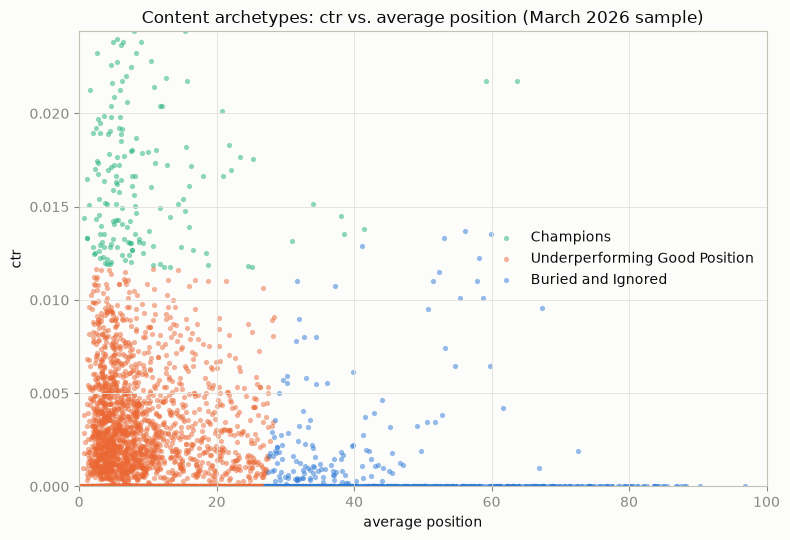

In [7]:
import matplotlib.pyplot as plt

# validated categorical triplet (colorblind-safe for scatter/all-pairs use), fixed order by archetype
archetype_colors = {
    "Champions": "#1baf7a",
    "Underperforming Good Position": "#eb6834",
    "Buried and Ignored": "#2a78d6",
}

# sample for a readable figure -- the full 125,645 points would be one overplotted blob
plot_sample = features.sample(n=4000, random_state=42)

fig, ax = plt.subplots(figsize=(8, 5.5), facecolor="#fcfcfb")
ax.set_facecolor("#fcfcfb")

for archetype, color in archetype_colors.items():
    subset = plot_sample[plot_sample["archetype"] == archetype]
    ax.scatter(
        subset["avg_position"], subset["ctr"],
        s=14, alpha=0.5, color=color, label=archetype, linewidths=0,
    )

# clip the VIEW only (a few extreme-position outliers exist) -- underlying data/model untouched
ax.set_xlim(0, 100)
ax.set_ylim(0, plot_sample["ctr"].quantile(0.99))

ax.set_xlabel("average position", color="#0b0b0b")
ax.set_ylabel("ctr", color="#0b0b0b")
ax.set_title("Content archetypes: ctr vs. average position (March 2026 sample)", color="#0b0b0b")
ax.tick_params(colors="#898781")
ax.grid(color="#e1e0d9", linewidth=0.6)
for spine in ax.spines.values():
    spine.set_color("#c3c2b7")
ax.legend(frameon=False, labelcolor="#0b0b0b")

fig.tight_layout()
figure_path = figures_dir / "archetype_scatter.png"
fig.savefig(figure_path, dpi=150)
print(f"wrote figure to {figure_path.resolve()}")
plt.show()


This notebook exports two files to work/outputs/: action_playbook_queue.csv, the full ranked queue of 125,645 items with archetype, reason code, action, and score (regenerated each run, not committed to git per the CI leak-guard), and playbook_metadata.json, which is committed, holding the snapshot month, eligible item count, GSC coverage percentage, the volume floor, k, per-archetype counts/percentages/mean ctr/mean position, and the validated silhouette range from w05/w06. work/figures/archetype_scatter.png is also committed, a sampled scatter of ctr vs. average position colored by archetype, showing the three groups visually separating: Champions cluster in the good-position, high-ctr region, Underperforming shares Champions' position range but sits far lower on ctr, and Buried sits almost entirely in the poor-position region near zero ctr. These three files are what next week's paper builds its numbers and visuals from.

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.